In [98]:
#import relevant libraries
import sys
import os
import glob

import numpy as np
import scipy as sp
import pandas as pd
import matplotlib as mpl
import datetime as dt8
import math
import matplotlib.pyplot as plt
import decimal

import dabest
import NLCLIMB
import NLMATH


#NOTE: SUPPRESSES WARNINGS!

import warnings

import warnings


warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)


In [99]:
#initial file processing
path0 = "C:\\Users\\lnico\\"
pathhome = "D:\\"
pathlab = "C:\\Users\\User\\"
pathoffice = "C:\\Users\\Star\\"
specifiedpath = pathhome

mainpath = "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data compilation\\Together\\1. Raw\\"
savefolder = specifiedpath +  "ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data compilation\\Together\\2. Processed" 

In [100]:
responder_one = "ACR [ATR]"
responder_two = "eOPN3 [ATR]"
# responder_three = "KCR"
responder_four = "eOPN3"
wt = "w1118 x eOPN3"
wtname = "w1118"
driver = "elav"


responderlist = [ responder_one, responder_two,responder_four]
#responderlist = [responder_one, responder_two, responder_three, responder_four]
df_totalresponder = pd.DataFrame()



In [101]:
def removingextraline(df1):  #only takes 22 seconds of the entire timeline
    df = df1.reset_index(drop=True)
    df['Seconds'] = round(df['Seconds'],1)
    line = df[(df['Seconds'] > 22.0)].index
    df = df.drop(line)
    
    return df

In [102]:
r1_filename = specifiedpath + mainpath + driver + " x " + responder_one
r2_filename = specifiedpath + mainpath + driver + " x " + responder_two
# r3_filename = specifiedpath + mainpath + driver + " x " + responder_three
r4_filename = specifiedpath + mainpath + driver + " x " + responder_four


df_r1, fpsexpt = NLCLIMB.trans(r1_filename, driver, wtname)
dfr1 = NLCLIMB.fivesecondrule(NLCLIMB.generation(df_r1, driver))

df_r2, fpsexpt = NLCLIMB.trans(r2_filename, driver, wtname)
dfr2 = NLCLIMB.fivesecondrule(NLCLIMB.generation(df_r2, driver))

# df_r3, fpsexpt = NLCLIMB.trans(r3_filename, driver, wtname)
# dfr3 = NLCLIMB.fivesecondrule(NLCLIMB.generation(df_r3, driver))

df_r4, fpsexpt = NLCLIMB.trans(r4_filename, driver, wtname)
dfr4 = NLCLIMB.fivesecondrule(NLCLIMB.generation(df_r4, driver))

df_control, fpscontrol = NLCLIMB.control(specifiedpath + mainpath + wt, wt.split(" ")[0])
dfwt = NLCLIMB.fivesecondrule(NLCLIMB.generation(df_control, wt.split(" ")[0]))

In [103]:
#Y position
df_meanheight1=removingextraline(NLMATH.meangraph(NLMATH.calcgraph(dfr1,"Y.*")))
df_meanheight2=removingextraline(NLMATH.meangraph(NLMATH.calcgraph(dfr2,"Y.*")))
# df_meanheight3=removingextraline(NLMATH.meangraph(NLMATH.calcgraph(dfr3,"Y.*")))
df_meanheight4=removingextraline(NLMATH.meangraph(NLMATH.calcgraph(dfr4,"Y.*")))

df_meanheight_wt= removingextraline(NLMATH.meangraph(NLMATH.calcgraph(dfwt,"Y.*")))

#speed
df_meanspeed1=removingextraline(NLMATH.meangraph(NLMATH.calcgraph(dfr1,"Velocity.*")))
df_meanspeed2=removingextraline(NLMATH.meangraph(NLMATH.calcgraph(dfr2,"Velocity.*")))
# df_meanspeed3=removingextraline(NLMATH.meangraph(NLMATH.calcgraph(dfr3,"Velocity.*")))
df_meanspeed4=removingextraline(NLMATH.meangraph(NLMATH.calcgraph(dfr4,"Velocity.*")))

df_meanspeed_wt=removingextraline(NLMATH.meangraph(NLMATH.calcgraph(dfwt,"Velocity.*")))

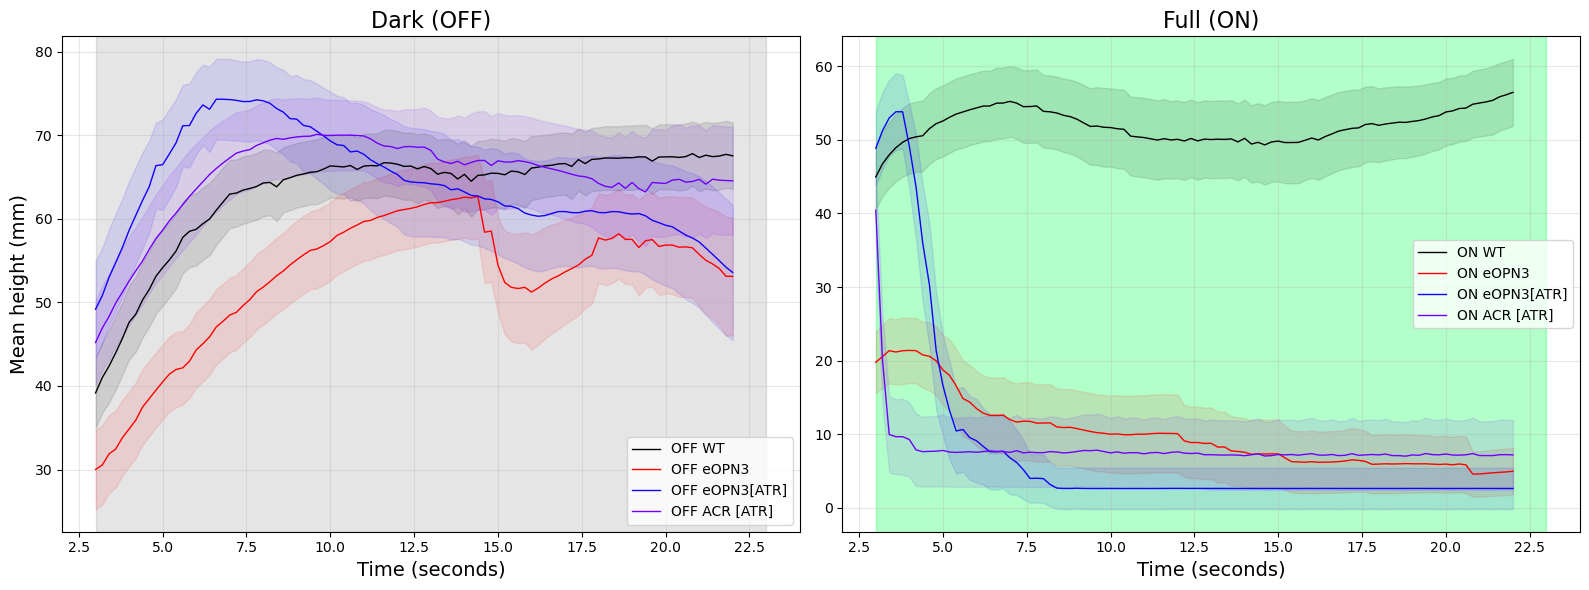

In [104]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Define your dataframes and colors
# genotypes = {
#     'WT': (df_meanheight_wt, '#000000'),
#     'Expt_22uW': (df_meanheight4, "#FF0000"),
#     'Expt_39uW': (df_meanheight3, "#FF7B00FF"),
#     'Expt [ATR]_22uW': (df_meanheight2, "#1100FF"),
#     'Expt [ATR]_39uW': (df_meanheight1, "#6F00FF"),
# }

genotypes = {
    'WT': (df_meanheight_wt, '#000000'),
    'eOPN3': (df_meanheight4, "#FF0000"),
    # 'KCR': (df_meanheight3, "#FF9900"),
    'eOPN3[ATR]': (df_meanheight2, "#1100FF"),
    'ACR [ATR]': (df_meanheight1, "#6F00FF"),
}

# LEFT PANEL - Dark/OFF conditions
axs[0].axvspan(3, 23, alpha=0.1, color="#000000", label="_nolegend_")

for genotype, (df, color) in genotypes.items():
    df_dark = df[df['ExperimentState'] == 'Dark']
    time = df_dark['Seconds']
    mean = df_dark['mean']
    ci = df_dark['CI']
    
    axs[0].plot(time, mean, color=color, linewidth=1, label=f'OFF {genotype}')
    axs[0].fill_between(time, mean - ci, mean + ci, 
                        color=color, alpha=0.1, label="_nolegend_")

axs[0].set_ylabel('Mean height (mm)', fontsize=14)
axs[0].set_xlabel('Time (seconds)', fontsize=14)
axs[0].set_title('Dark (OFF)', fontsize=16)
axs[0].legend(fontsize=10)
axs[0].grid(True, alpha=0.3)

# RIGHT PANEL - Full/ON conditions
axs[1].axvspan(3, 23, alpha=0.3, color="#00FF4C71", label="_nolegend_")

for genotype, (df, color) in genotypes.items():
    df_full = df[df['ExperimentState'] == 'Full']
    time = df_full['Seconds']
    mean = df_full['mean']
    ci = df_full['CI']
    
    axs[1].plot(time, mean, color=color, linewidth=1, label=f'ON {genotype}')
    axs[1].fill_between(time, mean - ci, mean + ci, 
                        color=color, alpha=0.1, label="_nolegend_")

axs[1].set_xlabel('Time (seconds)', fontsize=14)
axs[1].set_title('Full (ON)', fontsize=16)
axs[1].legend(fontsize=10)
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

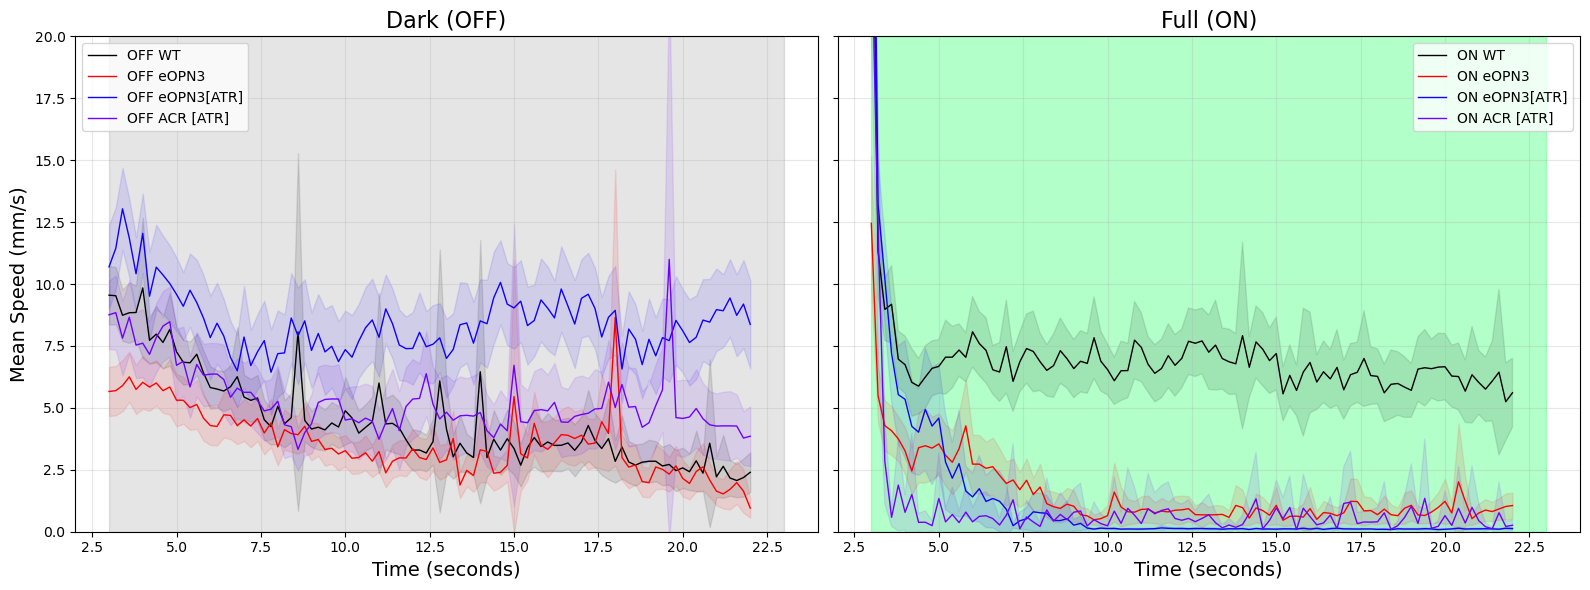

In [105]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Define your dataframes and colors
# genotypes = {
#     'WT': (df_meanspeed_wt, '#000000'),
#     'Expt_22uW': (df_meanspeed4, "#FF0000"),
#     'Expt_39uW': (df_meanspeed3, "#FF7B00FF"),
#     'Expt [ATR]_22uW': (df_meanspeed2, "#1100FF"),
#     'Expt [ATR]_39uW': (df_meanspeed1, "#6F00FF"),
# }

genotypes = {
    'WT': (df_meanspeed_wt, '#000000'),
    'eOPN3': (df_meanspeed4, "#FF0000"),
    # 'KCR': (df_meanspeed3, "#FF9900"),
    'eOPN3[ATR]': (df_meanspeed2, "#1100FF"),
    'ACR [ATR]': (df_meanspeed1, "#6F00FF"),
}

# LEFT PANEL - Dark/OFF conditions
axs[0].axvspan(3, 23, alpha=0.1, color="#000000", label="_nolegend_")

for genotype, (df, color) in genotypes.items():
    df_dark = df[df['ExperimentState'] == 'Dark']
    time = df_dark['Seconds']
    mean = df_dark['mean']
    ci = df_dark['CI']
    
    axs[0].plot(time, mean, color=color, linewidth=1, label=f'OFF {genotype}')
    axs[0].fill_between(time, mean - ci, mean + ci, 
                        color=color, alpha=0.1, label="_nolegend_")

axs[0].set_ylabel('Mean Speed (mm/s)', fontsize=14)
axs[0].set_xlabel('Time (seconds)', fontsize=14)
axs[0].set_title('Dark (OFF)', fontsize=16)
axs[0].legend(fontsize=10)
axs[0].grid(True, alpha=0.3)

# RIGHT PANEL - Full/ON conditions
axs[1].axvspan(3, 23, alpha=0.3, color="#00FF4C71", label="_nolegend_")

for genotype, (df, color) in genotypes.items():
    df_full = df[df['ExperimentState'] == 'Full']
    time = df_full['Seconds']
    mean = df_full['mean']
    ci = df_full['CI']
    
    axs[1].plot(time, mean, color=color, linewidth=1, label=f'ON {genotype}')
    axs[1].fill_between(time, mean - ci, mean + ci, 
                        color=color, alpha=0.1, label="_nolegend_")

axs[1].set_xlabel('Time (seconds)', fontsize=14)
axs[1].set_title('Full (ON)', fontsize=16)
axs[1].legend(fontsize=10)
axs[1].grid(True, alpha=0.3)
plt.ylim(0, 20) 
plt.tight_layout()
plt.show()

## Height

In [106]:
def heightcalc(dfexpt, phrase):
    import pandas as pd
    import numpy as np 
        
    dfe_dark = dfexpt[(dfexpt['ExperimentState']== 'Dark')] 
    dfe_full = dfexpt[(dfexpt['ExperimentState']== 'Full')] 
    dfe_rec = dfexpt[(dfexpt['ExperimentState']== 'Recovery')]

    filterword = phrase + ".*"
    
    expts = [dfe_dark, dfe_full, dfe_rec]
    results = []
    for e in expts:
        filtereddf = e.filter(regex=filterword)
    
        match phrase:
            case "Y":
                result = getattr(filtereddf, "mean")(axis=0)
            case "Fall":
                result = getattr(filtereddf, "sum")(axis=0)/1
                
        results.append(result)
        
    awt=pd.DataFrame()
    awt[phrase]= results[0]
    awt['ExperimentState'] = "Dark"

    awt2=pd.DataFrame()
    awt2[phrase]=results[1]
    awt2['ExperimentState'] = "Full"
    
    awt2c=pd.DataFrame()
    awt2c[phrase]=results[2]
    awt2c['ExperimentState'] = "Recovery"

    awt2b = pd.concat([awt, awt2, awt2c]).reset_index()
    
    return awt2b

In [ ]:
df_heightlist = pd.DataFrame()
for n in responderlist:
    openPath = specifiedpath + mainpath
    filename = openPath + driver + " x " + n
    df_expt, fpsexpt = NLCLIMB.trans(filename, driver, wtname)
    dfexpt = NLCLIMB.fivesecondrule(NLCLIMB.generation(df_expt, driver))
    df_h = heightcalc(dfexpt,  "Y")
    df_h["Type"] = n
    df_h['cross'] = driver + " x " + n + "_"+ df_h['index'].str.split(" ").str[1]
    df_h = df_h.drop(columns = ['index'])
    df_heightlist = pd.concat([df_heightlist, df_h], axis=0)

#wt part:
df_control, fpscontrol = NLCLIMB.control(openPath + wt, wt.split(" ")[0])
dfwt = NLCLIMB.fivesecondrule(NLCLIMB.generation(df_control, wt.split(" ")[0]))
df_sh = heightcalc(dfwt,  "Y")
df_sh["Type"] = "WT"
df_sh['cross'] = wt + "_"+ df_sh['index'].str.split(" ").str[1]
df_sh = df_sh.drop(columns = ['index'])
df_heightlist = pd.concat([df_heightlist, df_sh], axis=0)


df_heightlist['genre'] = df_heightlist['ExperimentState'] + " " + df_heightlist['Type']

df_heightonly = df_heightlist.copy()
df_heightonly

,Y,ExperimentState,Type,cross,genre
0,49.096084,Dark,ACR [ATR],elav x ACR [ATR]_Y_1,Dark ACR [ATR]
1,72.157563,Dark,ACR [ATR],elav x ACR [ATR]_Y_2,Dark ACR [ATR]
2,51.633445,Dark,ACR [ATR],elav x ACR [ATR]_Y_3,Dark ACR [ATR]
3,77.647399,Dark,ACR [ATR],elav x ACR [ATR]_Y_4,Dark ACR [ATR]
4,73.043623,Dark,ACR [ATR],elav x ACR [ATR]_Y_5,Dark ACR [ATR]
...,...,...,...,...,...
307,84.890937,Recovery,WT,w1118 x eOPN3_Y_145,Recovery WT
308,80.367503,Recovery,WT,w1118 x eOPN3_Y_147,Recovery WT
309,74.789558,Recovery,WT,w1118 x eOPN3_Y_148,Recovery WT
310,41.106762,Recovery,WT,w1118 x eOPN3_Y_149,Recovery WT


In [108]:
df_heightonly['genre'].unique()

array(['Dark ACR [ATR]', 'Full ACR [ATR]', 'Recovery ACR [ATR]',
       'Dark eOPN3 [ATR]', 'Full eOPN3 [ATR]', 'Recovery eOPN3 [ATR]',
       'Dark eOPN3', 'Full eOPN3', 'Recovery eOPN3', 'Dark WT', 'Full WT',
       'Recovery WT'], dtype=object)

In [109]:
# df_heightonly['genre'] = df_heightonly['genre'].replace({
#     'Dark WT': 'OFF WT', 'Full WT': 'ON WT',
#     'Dark eOPN3': 'OFF Expt_22uW', 'Full eOPN3': 'ON Expt_22uW',
#     'Dark eOPN3_Full': 'OFF Expt_39uW', 'Full eOPN3_Full': 'ON Expt_39uW',
#     'Dark eOPN3 [ATR]': 'OFF Expt [ATR]_22uW', 'Full eOPN3 [ATR]': 'ON Expt [ATR]_22uW',
#     'Dark eOPN3 [ATR]_Full': 'OFF Expt [ATR]_39uW', 'Full eOPN3 [ATR]_Full': 'ON Expt [ATR]_39uW'
# })

# height_dabest = dabest.load(
#     data=df_heightonly, 
#     idx=(("OFF WT", "ON WT"), 
#          ("OFF Expt_22uW", "ON Expt_22uW"), 
#          ("OFF Expt_39uW", "ON Expt_39uW"),
#          ("OFF Expt [ATR]_22uW", "ON Expt [ATR]_22uW"), 
#          ("OFF Expt [ATR]_39uW", "ON Expt [ATR]_39uW")),
#     x="genre", 
#     y="Y", 
#     paired="baseline", 
#     id_col="cross"
# )

In [119]:
height_dabest = dabest.load(
    data=df_heightonly, 
    idx=(("Dark WT", "Full WT"), 
         ("Dark eOPN3", "Full eOPN3"), 
         ("Dark eOPN3 [ATR]", "Full eOPN3 [ATR]"),
         ("Dark ACR [ATR]", "Full ACR [ATR]")),
    x="genre", 
    y="Y", 
    paired="baseline", 
    id_col="cross"
)


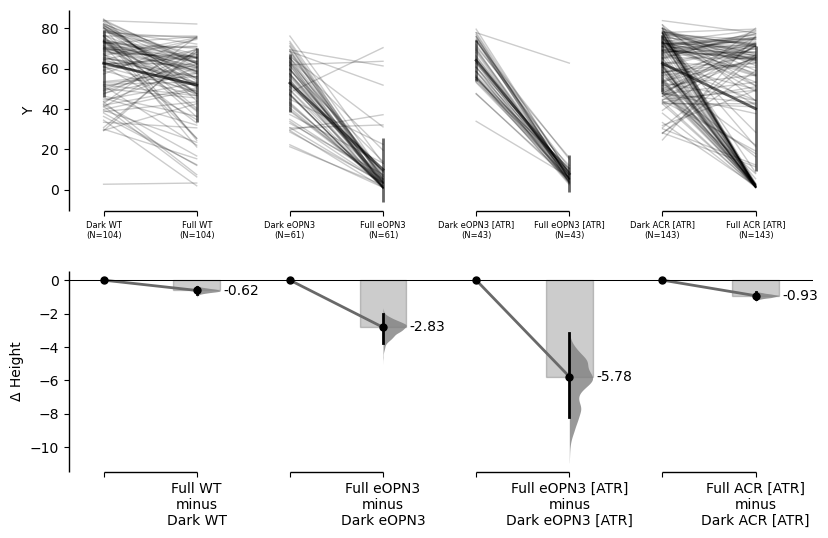

In [120]:
common_style = {'fontsize_rawxlabel': 6, 'fontsize_rawylabel': 10, 'fontsize_contrastxlabel': 10,
                'fontsize_contrastylabel': 10, 'fontsize_delta2label': 10, 'contrast_marker_size': 5}

heightdf = height_dabest.hedges_g.plot(contrast_label="Δ Height", **common_style);

# elavdf.axes[0].set_xticklabels(["OFF WT", "ON WT", 
#                                 "OFF Expt_22uW", "ON Expt_22uW",
#                                 "OFF Expt_39uW", "ON Expt_39uW",
#                                 "OFF Expt \n[ATR]_22uW", "ON Expt \n[ATR]_22uW",
#                                 "OFF Expt \n[ATR]_39uW", "ON Expt \n[ATR]_39uW"], fontsize=8)

## Velocity

In [112]:
df_responderlist = pd.DataFrame()
for n in responderlist:
    openPath = specifiedpath + mainpath
    filename = openPath + driver + " x " + n
    df_expt, fpsexpt = NLCLIMB.trans(filename, driver, wtname)
    dfexpt = NLCLIMB.fivesecondrule(NLCLIMB.generation(df_expt, driver))
    df_sp = NLMATH.velodabest(dfexpt, n, "Velocity").reset_index(drop=False)
    df_sp['cross'] = driver + " x " + n + "_"+ df_sp['index'].str.split(" ").str[1]
    df_sp = df_sp.drop(columns = ['index'])
    df_responderlist = pd.concat([df_responderlist, df_sp], axis=0)

#wt part:
df_control, fpscontrol = NLCLIMB.control(openPath + wt, wt.split(" ")[0])
dfwt = NLCLIMB.fivesecondrule(NLCLIMB.generation(df_control, wt.split(" ")[0]))
df_sw = NLMATH.velodabest(dfwt, "WT", "Velocity").reset_index(drop=False)
df_sw['cross'] = wt + "_"+ df_sw['index'].str.split(" ").str[1]
df_sw = df_sw.drop(columns = ['index'])
df_responderlist = pd.concat([df_responderlist, df_sw], axis=0)

df_responderlist

,Velocity,ExperimentState,Type,cross
0,8.608379,Dark,ACR [ATR],elav x ACR [ATR]_Velocity_1
1,7.954052,Dark,ACR [ATR],elav x ACR [ATR]_Velocity_2
2,8.854270,Dark,ACR [ATR],elav x ACR [ATR]_Velocity_3
3,7.135193,Dark,ACR [ATR],elav x ACR [ATR]_Velocity_4
4,5.968082,Dark,ACR [ATR],elav x ACR [ATR]_Velocity_5
...,...,...,...,...
307,0.277800,Recovery,WT,w1118 x eOPN3_Velocity_145
308,2.369460,Recovery,WT,w1118 x eOPN3_Velocity_147
309,0.507315,Recovery,WT,w1118 x eOPN3_Velocity_148
310,0.614730,Recovery,WT,w1118 x eOPN3_Velocity_149


In [113]:
df_responderlist['genre'] = df_responderlist['ExperimentState'] + " " + df_responderlist['Type']

df_responders = df_responderlist.copy()

In [114]:
# df_responders['genre'] = df_responders['genre'].replace({
#     'Dark WT': 'OFF WT', 'Full WT': 'ON WT',
#     'Dark eOPN3': 'OFF Expt_22uW', 'Full eOPN3': 'ON Expt_22uW',
#     'Dark eOPN3_Full': 'OFF Expt_39uW', 'Full eOPN3_Full': 'ON Expt_39uW',
#     'Dark eOPN3 [ATR]': 'OFF Expt [ATR]_22uW', 'Full eOPN3 [ATR]': 'ON Expt [ATR]_22uW',
#     'Dark eOPN3 [ATR]_Full': 'OFF Expt [ATR]_39uW', 'Full eOPN3 [ATR]_Full': 'ON Expt [ATR]_39uW'
# })

# velocity_dabest = dabest.load(
#     data=df_responders, 
#     idx=(("OFF WT", "ON WT"), 
#          ("OFF Expt_22uW", "ON Expt_22uW"), 
#          ("OFF Expt_39uW", "ON Expt_39uW"),
#          ("OFF Expt [ATR]_22uW", "ON Expt [ATR]_22uW"), 
#          ("OFF Expt [ATR]_39uW", "ON Expt [ATR]_39uW")),
#     x="genre", 
#     y="Velocity", 
#     paired="baseline", 
#     id_col="cross"
# )


In [115]:
velocity_dabest = dabest.load(
    data=df_responders, 
    idx=(("Dark WT", "Full WT"), 
         ("Dark eOPN3", "Full eOPN3"), 
         ("Dark eOPN3 [ATR]", "Full eOPN3 [ATR]"),
         ("Dark ACR [ATR]", "Full ACR [ATR]")),
    x="genre", 
    y="Velocity", 
    paired="baseline", 
    id_col="cross"
)


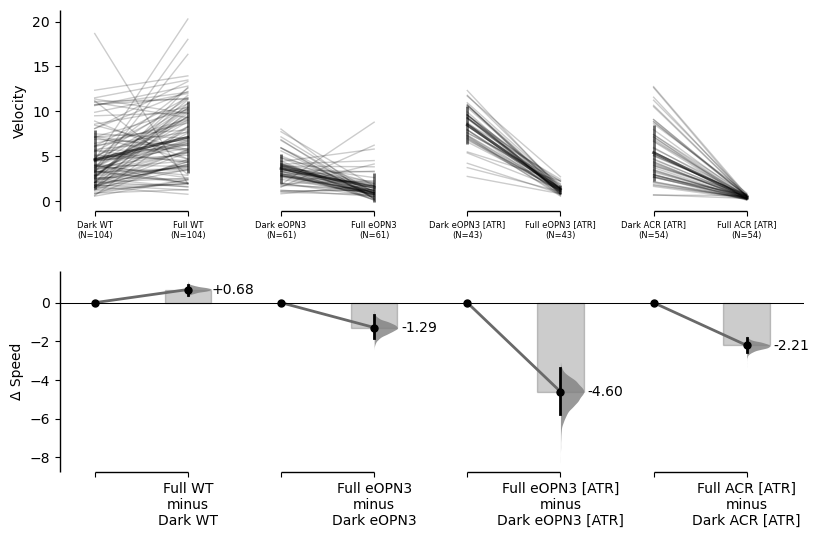

In [116]:
common_style = {'fontsize_rawxlabel': 6, 'fontsize_rawylabel': 10, 'fontsize_contrastxlabel': 10,
                'fontsize_contrastylabel': 10, 'fontsize_delta2label': 10, 'contrast_marker_size': 5}

elavdf = velocity_dabest.hedges_g.plot(contrast_label="Δ Speed", **common_style);

# elavdf.axes[0].set_xticklabels(["OFF WT", "ON WT", 
#                                 "OFF Expt_22uW", "ON Expt_22uW",
#                                 "OFF Expt_39uW", "ON Expt_39uW",
#                                 "OFF Expt \n[ATR]_22uW", "ON Expt \n[ATR]_22uW",
#                                 "OFF Expt \n[ATR]_39uW", "ON Expt \n[ATR]_39uW"], fontsize=8)